### Loading ad preping the data

In [1]:
import pandas as pd
import numpy as np
%pip install hdbscan

summary_df = pd.read_csv("summary.csv")
static_df = pd.read_csv("static.csv")
df = summary_df.merge(static_df, on = "RunID", how = "inner")
feature_cols = [
        # "max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        # "max_ram_used_mb",
        "mean_ram_used_mb",
        "time_per_1000_steps_sec"
    ]
assert len(df) == len(summary_df), "Different number of entries"
# print(df.head())
print(static_df["game_name"].value_counts(normalize=True))
print(static_df["training_type"].value_counts(normalize=True))
display(df[df["mean_cpu_usage_percent"] < 0][["RunID", "mean_cpu_usage_percent", "cpu"]])
display(df[["max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        "max_ram_used_mb",
        "mean_ram_used_mb"
        ]].corr())

Note: you may need to restart the kernel to use updated packages.
game_name
3DBall               0.460666
3DBallHard           0.339121
Crawler              0.071580
GridFoodCollector    0.057229
PushBlock            0.029943
Hallway              0.021262
Pyramids             0.004429
Walker               0.004429
Worm                 0.004429
Sorter               0.003898
GridWorld            0.003012
Name: proportion, dtype: float64
training_type
ppo    0.980865
sac    0.019135
Name: proportion, dtype: float64


,RunID,mean_cpu_usage_percent,cpu
5557,20260106-235341,-0.838145,AMD Ryzen 7 9800X3D 8-Core Processor
5559,20260107-000445,-0.829164,AMD Ryzen 7 9800X3D 8-Core Processor


,max_cpu_usage_percent,mean_cpu_usage_percent,max_ram_used_mb,mean_ram_used_mb
max_cpu_usage_percent,1.000000,0.970116,0.630565,0.657114
mean_cpu_usage_percent,0.970116,1.000000,0.660429,0.694620
max_ram_used_mb,0.630565,0.660429,1.000000,0.991566
mean_ram_used_mb,0.657114,0.694620,0.991566,1.000000


In [78]:
pd.crosstab(df["game_name"], df["training_type"])

training_type,ppo,sac
game_name,,
3DBall,2571,29
3DBallHard,1902,12
Crawler,386,18
GridFoodCollector,316,7
GridWorld,15,2
Hallway,112,8
PushBlock,162,7
Pyramids,18,7
Sorter,18,4


In [79]:
def create_feature_data_frame(df : pd.DataFrame) -> pd.DataFrame:
    assert (df["max_steps"] > 0).all(), "Runs with 0 steps found"
    df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)
    return df[feature_cols]
    
def get_sanitized_mask(X : pd.DataFrame):
    sanitized_mask =(
        # (X["max_cpu_usage_percent"] >= 0) &
        (X["mean_cpu_usage_percent"] >= 0) &
        # (X["max_ram_used_mb"] >= 0) &
        (X["mean_ram_used_mb"] >= 0) &
        (X["time_per_1000_steps_sec"] > 0)
    )
    return sanitized_mask

def get_subsample_mask(sanitized_df : pd.DataFrame, instances_per_machine_game_pair = 5):
    subsampled = sanitized_df.groupby(["cpu", "game_name", "training_type"], group_keys=False).apply(
        lambda x: x.sample(
            n=min(len(x), instances_per_machine_game_pair),
            random_state=42
        )
    )
    used_run_ids = set(subsampled["RunID"])
    return sanitized_df["RunID"].isin(used_run_ids)

X = create_feature_data_frame(df)
display(df["time_per_1000_steps_sec"].describe())
sanitized_mask = get_sanitized_mask(X)
X_sanitized = X[sanitized_mask].copy()
df_sanitized = df[sanitized_mask].copy()
subsample_mask = get_subsample_mask(df_sanitized)

X_sanitized = X_sanitized[subsample_mask]
df_sanitized = df_sanitized[subsample_mask]

def get_sanitized_and_subsampled_features_and_org_df(df : pd.DataFrame, subsample = True, subsample_cap = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = create_feature_data_frame(df)
    sanitized_mask = get_sanitized_mask(X)
    X_sanitized = X[sanitized_mask].copy()
    df_sanitized = df[sanitized_mask].copy()
    if subsample:
        subsample_mask = get_subsample_mask(df_sanitized, instances_per_machine_game_pair=subsample_cap)
        X_sanitized = X_sanitized[subsample_mask].copy()
        df_sanitized = df_sanitized[subsample_mask].copy()
    return X_sanitized, df_sanitized

print(f"Number of significantly long runs (time_per_1000_stpes_sec > 10) : {len(X[X["time_per_1000_steps_sec"]>10])}")
print(f"Number of deleted entries : {len(X) - len(X_sanitized)}")
print(f"Number of entires remainig : {len(X_sanitized)}")

count    5642.000000
mean        1.363535
std        15.026194
min         0.210316
25%         0.343475
50%         0.423929
75%         0.583976
max       912.552125
Name: time_per_1000_steps_sec, dtype: float64

Number of significantly long runs (time_per_1000_stpes_sec > 10) : 83
Number of deleted entries : 5362
Number of entires remainig : 282


In [80]:
filtered = (df["game_name"] == "3DBall") & (df["training_type"] == "sac")
X_sanitized[filtered].describe()

/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_2867/1868267825.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_sanitized[filtered].describe()


,mean_cpu_usage_percent,mean_ram_used_mb,time_per_1000_steps_sec
count,15.000000,15.000000,15.000000
mean,23.265266,8197.712306,10.409248
std,5.585442,7196.852216,10.116320
min,16.166667,2904.025830,2.918337
25%,18.869939,2965.551459,4.159030
50%,22.218167,3591.258325,6.029525
75%,26.581125,17751.552675,11.825956
max,33.568833,18245.840000,39.201016


In [81]:
import matplotlib.pyplot as plt

def plot_distribuiton_of_features() -> None:        
    for col in feature_cols:
        plt.figure()
        plt.hist(X[col].dropna(), bins=100)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    plt.figure()
    selected = X[X["time_per_1000_steps_sec"] > 10]
    ax = plt.axes()
    ax.set_xscale("log")
    plt.hist(selected["time_per_1000_steps_sec"].dropna(), bins=100)
    
    plt.title(f"Distribution of time_per_1000_steps_sec")
    plt.xlabel("time_per_1000_steps_sec")
    plt.ylabel("Count")
    plt.show()
    
# plot_distribuiton_of_features()


In [82]:
print(static_df.cpu.unique())
print(len(static_df[static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor"]))
# test = static_df[static_df["cpu"] == "Apple M1"]
# print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor") & (static_df["training_type"] == "sac")]
print(test["training_type"].value_counts())
print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "Apple M1") & (static_df["training_type"] == "sac")]
print(len(test))

['AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD' 'Apple M2'
 'AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD'
 'AMD Ryzen 7 9800X3D 8-Core Processor'
 'AMD Ryzen 7 5700X 8-Core Processor' 'Apple M1']
4144
training_type
sac    8
Name: count, dtype: int64
game_name
Crawler              1
GridFoodCollector    1
Hallway              1
PushBlock            1
Pyramids             1
Sorter               1
Walker               1
Worm                 1
Name: count, dtype: int64
38


In [83]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_scaled_df_and_np(X_sanitized : pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    scaler = RobustScaler()
    X_log = X_sanitized.copy()
    X_log["time_per_1000_steps_sec"] = np.log1p(X_log["time_per_1000_steps_sec"])
    # X_log["mean_ram_used_mb"] = np.log1p(X_log["mean_ram_used_mb"])
    X_scaled_as_array = scaler.fit_transform(X_log)
    X_scaled = pd.DataFrame(
        X_scaled_as_array,
        columns=X_sanitized.columns,
        index = X_sanitized.index
    )
    return X_scaled, X_scaled_as_array

def cluster(X_scaled_as_array : np.ndarray, n_init = "auto", n_clusters = 5) -> tuple[np.ndarray, KMeans]:
    clf = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init, init="k-means++")
    clusters = clf.fit_predict(X_scaled_as_array)    
    return clusters, clf
    
def cluster_and_show(n_init = "auto", n_clusters = 5) -> None:
    X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
    X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
    X_scaled.describe()

    X_scaled["clusters"] = cluster(X_scaled_as_array, n_init=n_init, n_clusters = n_clusters)[0]
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c = X_scaled["clusters"])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    
def show_clustered(X_scaled) -> None:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    clusters = X_scaled["cluster"].unique()

    for cluster in clusters:
        mask = X_scaled["cluster"] == cluster
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f"Cluster {cluster}"
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Clusters")
    plt.show()

In [84]:
import numpy as np

def show_clustered_3d_log(X_with_clusters) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    clusters = X_with_clusters["cluster"].unique()

    for cluster in clusters:
        mask = X_with_clusters["cluster"] == cluster
        ax.scatter(
            X_with_clusters.loc[mask, "mean_cpu_usage_percent"],
            X_with_clusters.loc[mask, "mean_ram_used_mb"],
            X_with_clusters.loc[mask, "time_per_1000_steps_sec"],
            label=f"Cluster {cluster}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="Clusters")
    plt.show()


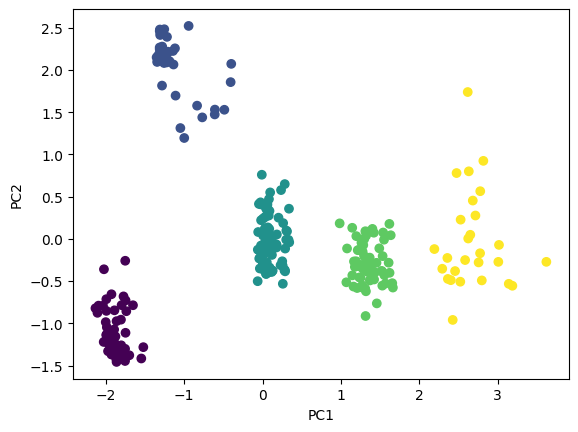

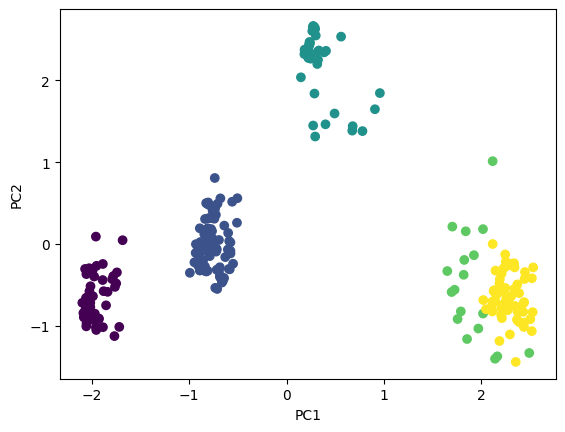

In [85]:
cluster_and_show(n_init="auto")
cluster_and_show(n_init=10)



In [86]:
import numpy as np
pca = PCA(n_components=2)
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
X_pca_1 = pca.fit_transform(X_scaled)
X_pca_2 = pca.fit_transform(X_scaled)

np.allclose(X_pca_1, X_pca_2)

labels_auto = KMeans(n_clusters=5, n_init="auto", random_state=42).fit_predict(X_scaled)
labels_10 = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_scaled)

(labels_auto == labels_10).mean()


0.25177304964539005

In [87]:
clusters, clf = cluster(X_scaled_as_array)
X_sanitized["cluster"] = clf.labels_
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
# print(cluster_summary)
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = X_sanitized["cluster"]
# static_cluster_3 = df_sanitized.loc[X_sanitized["cluster"] == 3]
# print(static_cluster_3)
# static_cluster_3.head()
# X_sanitized[X_sanitized["cluster"] == 3]["RunID"]
# X_sanitized
# print(summary_df_sanitized[X_sanitized["cluster"] == 3])
# df_sanitized[X_sanitized["cluster"] == 3]
# df_sanitized_with_clusters.head()
print(df_sanitized_with_clusters.columns)
print(X_sanitized["cluster"].value_counts())

Index(['RunID', 'final_reward', 'max_reward', 'time_to_max_reward_sec',
       'total_duration_sec', 'mean_policy_loss', 'mean_value_loss',
       'mean_entropy', 'final_entropy', 'max_cpu_usage_percent',
       'mean_cpu_usage_percent', 'max_ram_used_mb', 'mean_ram_used_mb',
       'mean_cpu_frequency', 'max_cpu_frequency', 'max_gpu_usage_percent',
       'mean_gpu_usage_percent', 'max_vram_used_mb', 'mean_vram_used_mb',
       'max_game_cpu_usage_percent', 'mean_game_cpu_usage_percent',
       'max_game_memory_usage_mb', 'mean_game_memory_usage_mb', 'os', 'cpu',
       'physical_cores', 'system_ram_gb', 'gpu', 'GPU_ram_mb', 'cuda_version',
       'training_type', 'game_name', 'batch_size', 'learning_rate',
       'buffer_size', 'beta', 'epsilon', 'lambd', 'num_epoch',
       'learning_rate_schedule', 'normalize', 'hidden_units', 'num_layers',
       'vis_encode_type', 'reward_extrinsic_gamma',
       'reward_extrinsic_strength', 'keep_checkpoints', 'max_steps',
       'time_horizon',

In [88]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"])

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,11,5,5,5,5,5,5,6,5,5,5
1,10,6,6,6,0,6,2,2,1,2,2
2,12,5,10,6,0,9,10,9,6,9,11
3,10,9,10,4,1,4,5,5,4,6,5
4,2,0,5,6,3,4,1,1,4,1,0


In [89]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
cluster,,
0,60,2
1,36,7
2,80,7
3,8,55
4,8,19


In [90]:
pd.crosstab(df_sanitized_with_clusters["game_name"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
game_name,,
3DBall,30,15
3DBallHard,15,10
Crawler,20,16
GridFoodCollector,20,7
GridWorld,7,2
Hallway,20,8
PushBlock,16,7
Pyramids,16,7
Sorter,16,4


In [91]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["cpu"])

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
0,57,0,5,0,0,0
1,0,37,0,5,0,1
2,0,0,0,0,41,46
3,15,0,0,0,38,10
4,11,1,0,0,4,11


In [92]:
display(cluster_summary)
display(df_sanitized_with_clusters)

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                     6.547516   4.205328   1.737500  22.218167   
1                    63.537707   5.619206  47.310843  73.460501   
2                    28.223162   5.695682  18.182631  42.872490   
3                    21.392644   5.199984   5.927114  31.885292   
4                    24.955462  12.148278   4.636000  55.329807   

        mean_ram_used_mb                                          \
                    mean          std          min           max   
cluster                                                            
0           13431.328908  4124.875173  8451.416748  21702.772358   
1           20857.958449  3334.315582  4220.743938  24726.250000   
2            3480.243657   205.772981  2742.599502   3867.798584   
3            5578.371377  4588.526283  2588.723328  18245.840000   
4            8789.612779  6350.193443  2823.696663  19947.100000   

        time_per_1000_steps_sec                                     
                           mean         std        min         max  
cluster                                                             
0                      1.272277    1.029403   0.412098    4.816704  
1                      2.695701    5.415037   0.230291   23.334980  
2                      1.926133    1.167688   0.627457    5.003188  
3                     11.089173    5.801763   3.805167   25.080158  
4                    109.998555  188.234627  19.792436  912.552125

,RunID,final_reward,max_reward,time_to_max_reward_sec,total_duration_sec,mean_policy_loss,mean_value_loss,mean_entropy,final_entropy,max_cpu_usage_percent,...,num_layers,vis_encode_type,reward_extrinsic_gamma,reward_extrinsic_strength,keep_checkpoints,max_steps,time_horizon,summary_freq,time_per_1000_steps_sec,cluster
29,20251123-040931,10.214287,10.214287,127.226204,127.226204,0.033689,0.559972,1.416729,1.414638,10.400000,...,2,simple,NaN,NaN,5,250000,512,12000,0.508905,0
31,20251123-042835,3.445076,3.692000,254.029999,258.188232,0.017186,0.191176,1.401258,1.375831,5.950000,...,3,simple,NaN,NaN,5,500000,2048,12000,0.516376,0
81,20251123-104448,1.660690,1.725176,129.753540,152.015106,0.024820,0.082402,1.410354,1.398661,6.166667,...,3,simple,NaN,NaN,5,250000,2048,12000,0.608060,0
118,20251123-153643,100.000008,100.000008,246.015533,676.480347,0.017768,0.018413,1.233955,1.118035,12.100000,...,2,simple,NaN,NaN,5,1000000,64,12000,0.676480,0
122,20251123-013820,100.000015,100.000015,35498.843750,35765.726560,0.035430,0.164357,1.359259,1.319901,63.799999,...,2,simple,NaN,NaN,5,1000000,256,12000,35.765727,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5639,20251221-042400,0.409266,0.446033,2627.455322,3328.799072,0.034694,0.027798,0.712965,0.154849,30.200001,...,3,simple,NaN,NaN,5,2000000,256,12000,1.664400,2
5640,20251228-012106,-1.039356,-0.729547,16647.429688,122156.382812,-2.193208,0.000698,1.031312,0.818584,36.599998,...,1,simple,NaN,NaN,5,1000000,256,10000,122.156383,4
5641,20251220-223532,100.000015,100.000015,366.650116,840.419006,0.025297,0.030919,1.226483,1.040945,39.799999,...,1,simple,NaN,NaN,5,1000000,512,12000,0.840419,2
5642,20251221-193027,0.049431,0.710895,259.797821,309.197815,0.035861,0.047049,1.420335,1.420728,42.933334,...,1,simple,NaN,NaN,5,250000,256,12000,1.236791,2


In [112]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

Q1 = X_sanitized.quantile(0.25)
Q3 = X_sanitized.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_sanitized < (Q1 - 1.5 * IQR)) | (X_sanitized > (Q3 + 1.5 * IQR))
outlier_rows = outlier_mask.any(axis=1)
len(outlier_rows == False)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
print(df_sanitized["game_name"].value_counts(normalize=True))
print(df_sanitized["training_type"].value_counts(normalize=True))

game_name
3DBall               0.159574
Crawler              0.127660
Hallway              0.099291
GridFoodCollector    0.095745
3DBallHard           0.088652
PushBlock            0.081560
Walker               0.081560
Pyramids             0.081560
Worm                 0.081560
Sorter               0.070922
GridWorld            0.031915
Name: proportion, dtype: float64
training_type
ppo    0.680851
sac    0.319149
Name: proportion, dtype: float64


In [94]:
from sklearn.metrics import silhouette_score
# For finding proper k
k_range = range(2, 20)

inertias = []
silhouette_scores = []


for k in k_range:
    # kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X_scaled_as_array)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_as_array, labels))
    
results = pd.DataFrame({"k" : k_range, "inertia" : inertias, "silhouette_score" : silhouette_scores})

print(results)

     k     inertia  silhouette_score
0    2  299.723470          0.560337
1    3  200.344961          0.454163
2    4  114.720510          0.519989
3    5   95.359946          0.480443
4    6   88.523818          0.414141
5    7   79.644236          0.410818
6    8   55.076659          0.498599
7    9   47.742184          0.482857
8   10   43.591259          0.462189
9   11   40.995600          0.460799
10  12   39.092969          0.460798
11  13   37.286754          0.461683
12  14   31.406090          0.468905
13  15   30.332341          0.420073
14  16   29.049506          0.389843
15  17   26.872587          0.351246
16  18   26.371258          0.350275
17  19   25.071919          0.342760


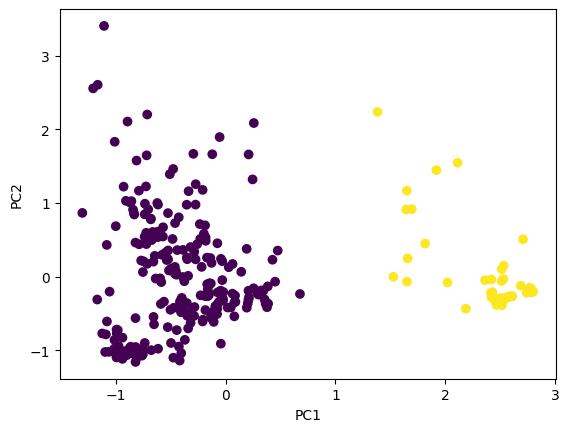

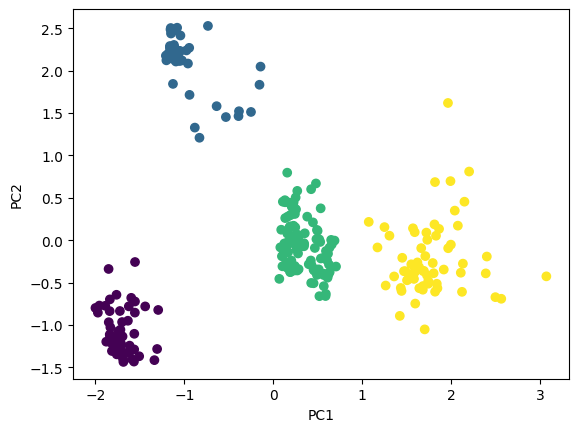

In [95]:
cluster_and_show(n_clusters=2)
cluster_and_show(n_clusters=4)

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                    20.283888  10.474634   1.737500  45.424243   
1                    63.351164   5.689665  47.310843  73.460501   

        mean_ram_used_mb                                          \
                    mean          std          min           max   
cluster                                                            
0            7164.304314  5472.115236  2588.723328  21702.772358   
1           20819.734517  3305.056306  4220.743938  24726.250000   

        time_per_1000_steps_sec                                   
                           mean        std       min         max  
cluster                                                           
0                     16.071425  70.823672  0.412098  912.552125  
1                      4.680674  14.212879  0.230291   90.034521

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,35,19,30,21,9,22,21,21,18,21,21
1,10,6,6,6,0,6,2,2,2,2,2


training_type,ppo,sac
cluster,,
0,156,82
1,36,8


cpu           AMD Ryzen 7 5700X 8-Core Processor      \
training_type                                ppo sac   
cluster                                                
0                                             55  28   
1                                              0   0   

cpu           AMD Ryzen 7 9800X3D 8-Core Processor      \
training_type                                  ppo sac   
cluster                                                  
0                                                0   0   
1                                               30   8   

cpu           AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD  \
training_type                                               ppo   
cluster                                                           
0                                                             5   
1                                                             0   

cpu           AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD Apple M1      \
training_type                                               ppo      ppo sac   
cluster                                                                        
0                                                             0       45  38   
1                                                             5        0   0   

cpu           Apple M2      
training_type      ppo sac  
cluster                     
0                   51  16  
1                    1   0

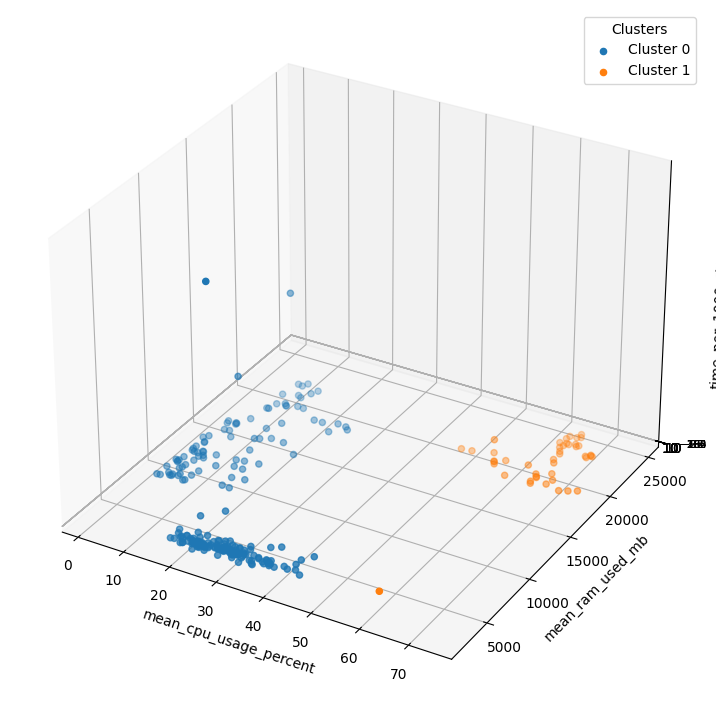

In [113]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
kmeans = KMeans(n_clusters=2, init="k-means++", n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled_as_array)
X_sanitized["cluster"] = labels
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
display(cluster_summary)
pd.Series(labels).value_counts()
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = labels
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"]))
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"]))
display(pd.crosstab(df_sanitized_with_clusters["cluster"], [df_sanitized_with_clusters[col] for col in ["cpu","training_type"]]))
show_clustered_3d_log(X_sanitized)


In [114]:
X_sanitized.corr()
X_sanitized["cluster"].value_counts()

cluster
0    238
1     44
Name: count, dtype: int64

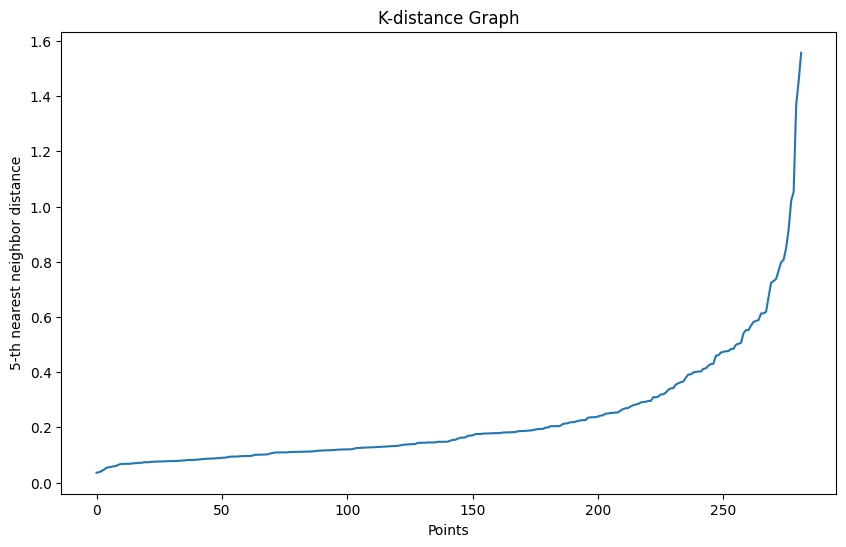

In [ ]:
X_sanitized_dbscan, df_sanitized_dbscan = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled_dbscan, X_scaled_as_array_dbscan = get_scaled_df_and_np(X_sanitized_dbscan)

from sklearn.neighbors import NearestNeighbors
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X_scaled_dbscan)
    distances, _ = neigh.kneighbors(X_scaled_dbscan)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

In [123]:
from sklearn.cluster import DBSCAN

def get_noise_from_eps_range(X_scaled_as_array_dbscan, eps_start, eps_end, eps_interval = 0.1) -> dict:
    noise_dict = {}
    eps_curr = eps_start
    while(eps_curr <= eps_end):            
        dbscan = DBSCAN(eps = eps_curr, min_samples = 5)
        labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
        noise_dict[eps_curr] = np.sum(labels == -1)/len(labels)
        eps_curr+=eps_interval
    return noise_dict

for k, v in get_noise_from_eps_range(X_scaled_as_array_dbscan, 0.2, 0.8).items():
    print(f"Epsilon = {k}, noise = {v}")

Epsilon = 0.2, noise = 0.24822695035460993
Epsilon = 0.30000000000000004, noise = 0.18439716312056736
Epsilon = 0.4, noise = 0.1099290780141844
Epsilon = 0.5, noise = 0.06028368794326241
Epsilon = 0.6, noise = 0.028368794326241134
Epsilon = 0.7, noise = 0.01773049645390071
Epsilon = 0.7999999999999999, noise = 0.01773049645390071


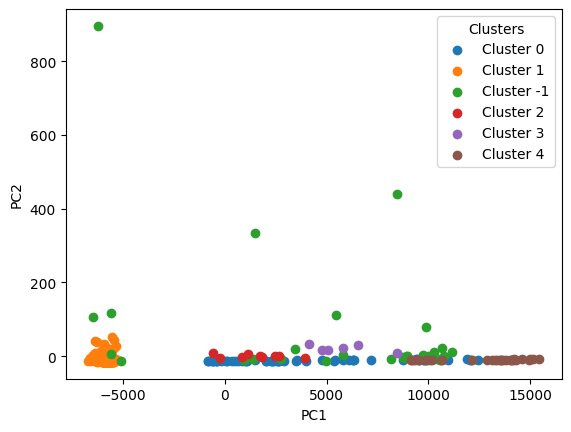

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   33.576596  20.839105   4.636000  73.460501   
 0                    5.913959   3.093942   1.737500  13.937805   
 1                   26.762510   6.090325  16.153333  45.424243   
 2                   14.812097   2.389855  10.859780  17.873667   
 3                   15.201970   2.481310  12.883333  18.477500   
 4                   65.602663   2.836500  58.899999  71.812450   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          14875.950662  5896.478482   2823.696663  20464.625000   
 0          13449.879540  4195.146977   8451.416748  21702.772358   
 1           3392.356724   312.983623   2588.723328   4047.323743   
 2          10822.874850  1416.797319   8734.066699  13210.906238   
 3          15092.268206  1531.484540  13448.825000  17725.320825   
 4          21771.303034  2166.027806  18424.992647  24726.250000   

        time_per_1000_steps_sec                                     
                           mean         std        min         max  
cluster                                                             
-1                    78.476244  185.036582   0.412098  912.552125  
 0                     1.169816    0.891853   0.471672    4.165636  
 1                     8.118052   12.593481   0.627457   69.295352  
 2                    14.014888    4.677775   8.201914   22.339438  
 3                    33.287111    9.926500  19.792436   46.317793  
 4                     0.601367    0.411916   0.230291    1.826646

cluster
 1    146
 0     58
 4     32
-1     31
 2      9
 3      6
Name: count, dtype: int64

In [116]:
dbscan = DBSCAN(eps = 0.4)
labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
X_sanitized_dbscan["cluster"] = labels
df_sanitized_dbscan["cluster"] = labels
show_clustered(X_sanitized_dbscan)

cluster_dbscan_summary = (
    X_sanitized_dbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_dbscan_summary)
X_sanitized_dbscan["cluster"].value_counts()

In [99]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["game_name"]))

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,15,8,0,3,2,3
0,53,0,5,0,0,0
1,0,0,0,0,81,65
2,9,0,0,0,0,0
3,6,0,0,0,0,0
4,0,30,0,2,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,8,2,2,4,1,3,2,1,5,1,2
0,10,5,5,4,5,5,4,6,4,5,5
1,20,9,20,11,2,14,15,15,10,15,15
2,0,4,3,1,0,0,0,0,0,1,0
3,0,0,1,2,1,1,1,0,0,0,0
4,7,5,5,5,0,5,1,1,1,1,1


In [100]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan[df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor"]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["os"]))
display(pd.crosstab(df_sanitized_dbscan["cpu"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab( df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,5,1,1,2,1,1,1,0,2,0,1
0,5,5,5,4,5,5,4,6,4,5,5
2,0,4,3,1,0,0,0,0,0,1,0
3,0,0,1,2,1,1,1,0,0,0,0


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cluster,,,,,
-1,9,6,2,3,11
0,41,17,0,0,0
1,0,0,81,65,0
2,9,0,0,0,0
3,6,0,0,0,0
4,0,0,0,0,32


os,Windows 11,macOS
cluster,,
-1,26,5
0,58,0
1,0,146
2,9,0
3,6,0
4,32,0


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cpu,,,,,
AMD Ryzen 7 5700X 8-Core Processor,65,18,0,0,0
AMD Ryzen 7 9800X3D 8-Core Processor,0,0,0,0,38
"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",0,5,0,0,0
"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",0,0,0,0,5
Apple M1,0,0,83,0,0
Apple M2,0,0,0,68,0


cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,15,8,0,3,2,3
0,53,0,5,0,0,0
1,0,0,0,0,81,65
2,9,0,0,0,0,0
3,6,0,0,0,0,0
4,0,30,0,2,0,0


In [101]:
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "Apple M2")]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor")]["game_name"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,2,5,5,5,5,5,5
sac,5,5,5,1,0,0,0,0,0,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,5,5,5,5,5,5,5
sac,5,5,5,4,2,2,1,1,1,1,1


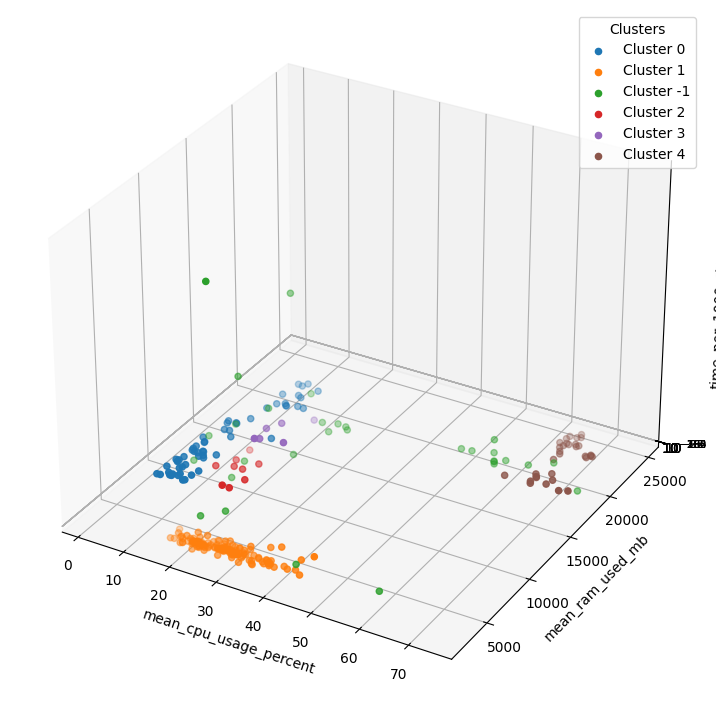

In [117]:

show_clustered_3d_log(X_sanitized_dbscan)

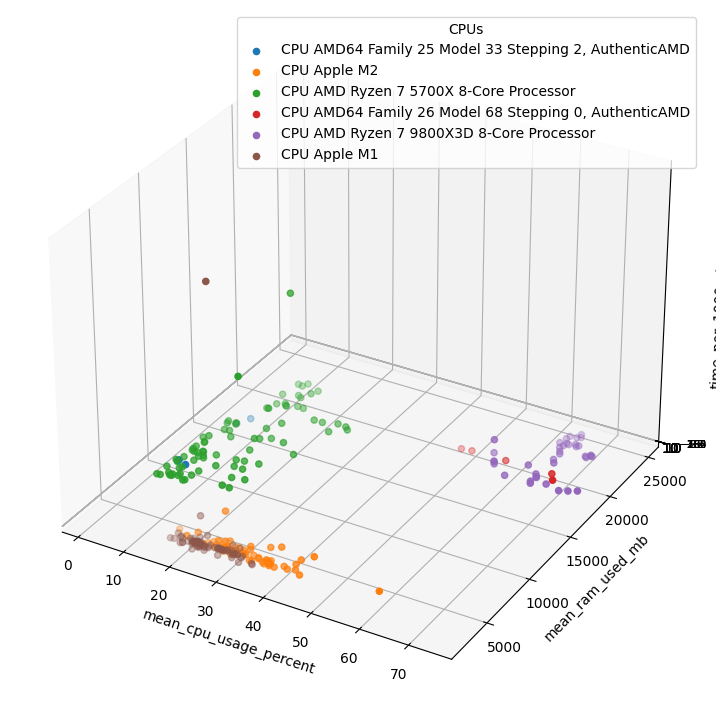

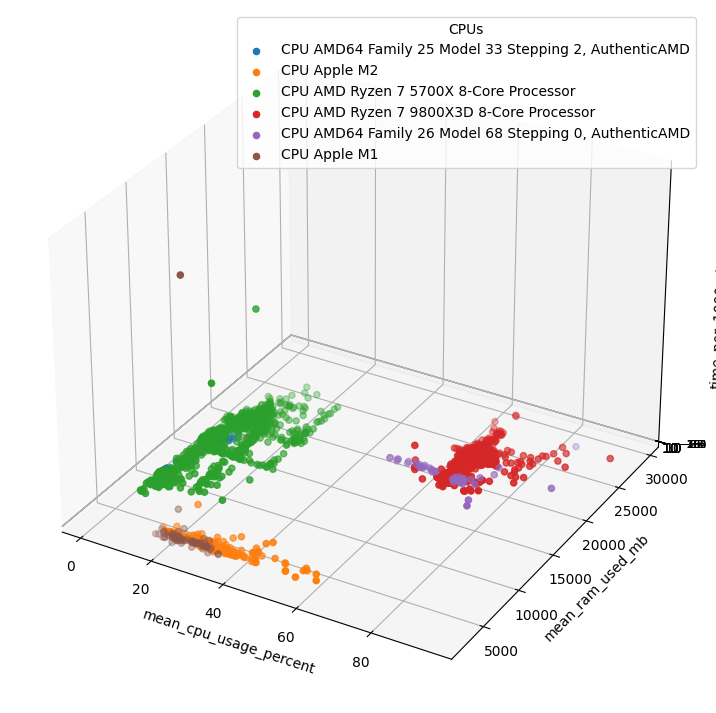

In [103]:
def show_by_cpu_3d_log(X) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    cpus = X["cpu"].unique()

    for cpu in cpus:
        mask = X["cpu"] == cpu
        ax.scatter(
            X.loc[mask, "mean_cpu_usage_percent"],
            X.loc[mask, "mean_ram_used_mb"],
            X.loc[mask, "time_per_1000_steps_sec"],
            label=f"CPU {cpu}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="CPUs")
    plt.show()

show_by_cpu_3d_log(df_sanitized_dbscan)
show_by_cpu_3d_log(df)

In [104]:
display(static_df[["cpu", "system_ram_gb"]].drop_duplicates())
display(static_df[["gpu", "system_ram_gb"]].drop_duplicates())

,cpu,system_ram_gb
0,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",34265653248
153,Apple M2,8589934592
203,"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",66157809664
253,AMD Ryzen 7 9800X3D 8-Core Processor,66157809664
510,AMD Ryzen 7 5700X 8-Core Processor,34265653248
5561,Apple M1,8589934592


,gpu,system_ram_gb
0,NVIDIA GeForce RTX 5080,34265653248
153,Chipset Model: Apple M2,8589934592
203,NVIDIA GeForce RTX 5070 Ti,66157809664
5561,Chipset Model: Apple M1,8589934592


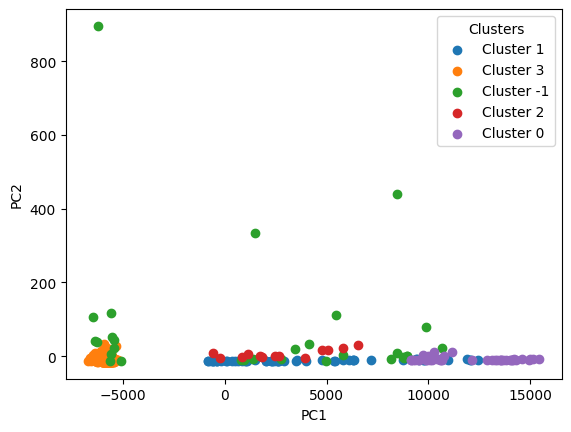

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   23.839727  14.404525   2.935714  58.044715   
 0                   63.668493   5.620690  47.310843  73.460501   
 1                    5.966209   3.095520   1.737500  13.937805   
 2                   14.813515   2.275680  10.859780  18.089561   
 3                   26.379274   5.617706  16.153333  42.872490   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          10916.748222  6315.181242   2823.696663  19947.100000   
 0          21254.082604  2115.877420  18424.992647  24726.250000   
 1          13508.590669  4208.329208   8451.416748  21702.772358   
 2          12060.410543  2285.885224   8734.066699  15827.716309   
 3           3387.313031   307.662628   2588.723328   4047.323743   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                    89.725358  185.115253  0.412098  912.552125  
 0                     2.716268    5.478977  0.230291   23.334980  
 1                     1.117257    0.804069  0.471672    3.740800  
 2                    19.980495   10.633020  8.201914   42.791030  
 3                     6.440534    8.745204  0.627457   48.449145

cluster
 3    140
 1     57
 0     42
-1     30
 2     13
Name: count, dtype: int64


cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,18,1,0,0,3,8
0,0,37,0,5,0,0
1,52,0,5,0,0,0
2,13,0,0,0,0,0
3,0,0,0,0,80,60


cpu           AMD Ryzen 7 5700X 8-Core Processor      \
training_type                                ppo sac   
cluster                                                
-1                                             3  15   
 0                                             0   0   
 1                                            52   0   
 2                                             0  13   
 3                                             0   0   

cpu           AMD Ryzen 7 9800X3D 8-Core Processor      \
training_type                                  ppo sac   
cluster                                                  
-1                                               0   1   
 0                                              30   7   
 1                                               0   0   
 2                                               0   0   
 3                                               0   0   

cpu           AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD  \
training_type                                               ppo   
cluster                                                           
-1                                                            0   
 0                                                            0   
 1                                                            5   
 2                                                            0   
 3                                                            0   

cpu           AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD Apple M1      \
training_type                                               ppo      ppo sac   
cluster                                                                        
-1                                                            0        0   3   
 0                                                            5        0   0   
 1                                                            0        0   0   
 2                                                            0        0   0   
 3                                                            0       45  35   

cpu           Apple M2      
training_type      ppo sac  
cluster                     
-1                   7   1  
 0                   0   0  
 1                   0   0  
 2                   0   0  
 3                  45  15

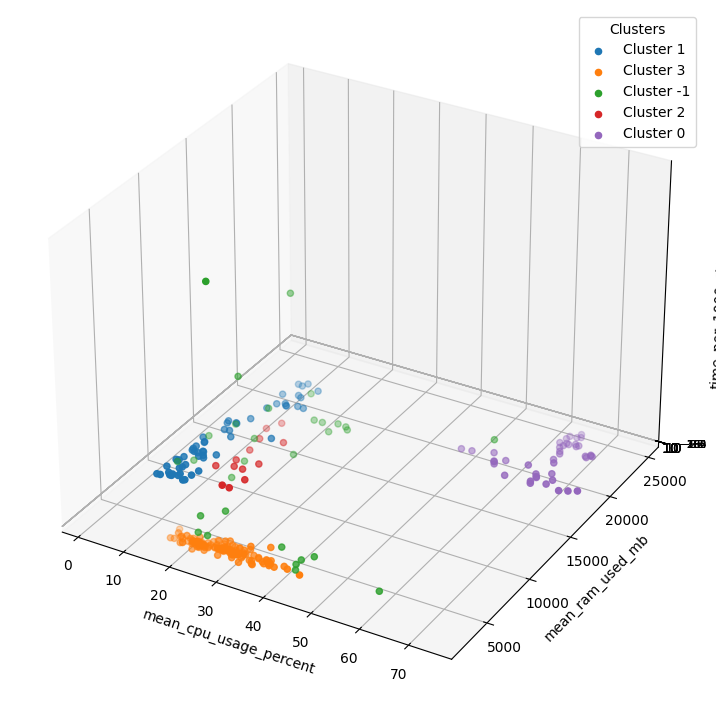

[0.32175116 0.23322566 0.02040368 0.16311188]


In [105]:
import hdbscan
X_sanitized_hdbscan, df_sanitized_hdbscan = get_sanitized_and_subsampled_features_and_org_df(df, subsample=True, subsample_cap=5)
X_scaled_hdbscan, X_scaled_as_array_hdbscan = get_scaled_df_and_np(X_sanitized_hdbscan)

hdbscan_clf = hdbscan.HDBSCAN(min_cluster_size=5)
hdbscan_clf.fit(X_scaled_as_array_hdbscan)
X_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
df_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
show_clustered(X_sanitized_hdbscan)

cluster_hdbscan_summary = (
    X_sanitized_hdbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_hdbscan_summary)
print(X_sanitized_hdbscan["cluster"].value_counts())
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["cpu"]))
display(pd.crosstab(df_sanitized_hdbscan["cluster"], [df_sanitized_hdbscan[col] for col in ["cpu","training_type"]]))
show_clustered_3d_log(X_sanitized_hdbscan)
print(hdbscan_clf.cluster_persistence_)

In [7]:
summ_test_df = pd.read_csv("../../data-collection/data/summary.csv")
stat_test_df = pd.read_csv("../../data-collection/data/static.csv")
print(len(summ_test_df))
print(len(stat_test_df))
len(stat_test_df[~stat_test_df["RunID"].isin(summ_test_df["RunID"])]["cpu"])


5700
5700


0

/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_2867/4230666366.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)


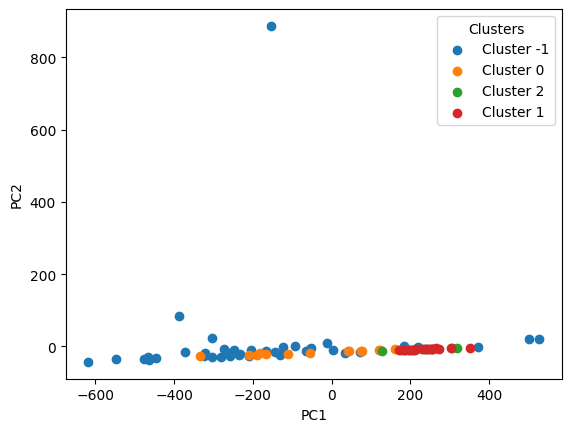

mean_cpu_usage_percent                                  \
                          mean       std        min        max   
cluster                                                          
-1                   23.800707  4.765175  16.166667  33.665873   
 0                   21.602110  0.871534  19.766667  22.958333   
 1                   26.926367  1.799978  23.560341  30.718750   
 2                   21.180493  0.497673  20.316667  21.932500   

        mean_ram_used_mb                                        \
                    mean         std          min          max   
cluster                                                          
-1           3054.785306  264.857044  2588.723328  3735.071429   
 0           3163.978918  155.106622  2872.615826  3368.729695   
 1           3443.322385   43.229621  3377.845837  3558.635539   
 2           3433.909192   59.710666  3335.119048  3525.937500   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                    37.577263  143.337469  0.790764  912.552125  
 0                     5.404961    1.775438  3.110792    9.671429  
 1                     1.660494    0.617895  0.627457    2.570319  
 2                     1.638240    0.324323  1.204850    2.014992

cluster
-1    40
 1    20
 0    14
 2     9
Name: count, dtype: int64


cpu,Apple M1
cluster,
-1,40
0,14
1,20
2,9


training_type,ppo,sac
cluster,,
-1,6,34
0,10,4
1,20,0
2,9,0


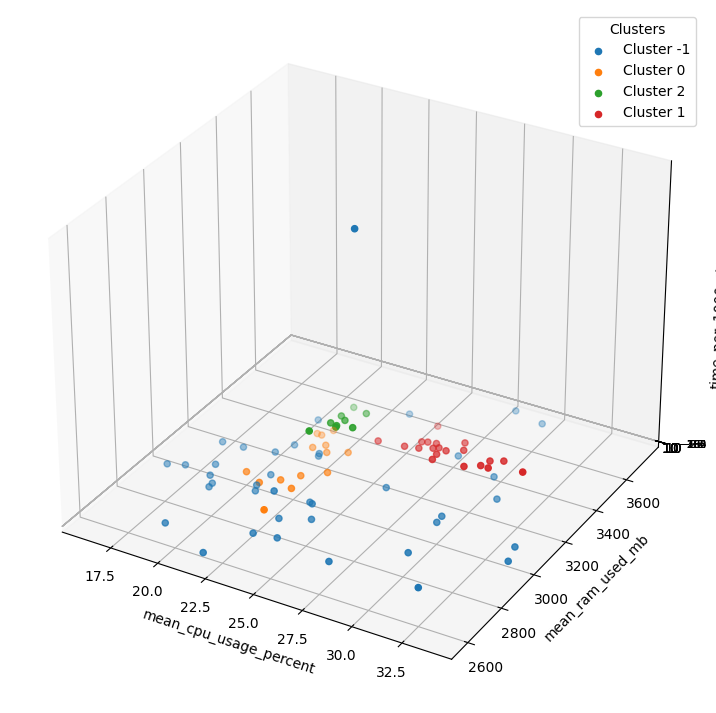

In [107]:
mine_sanitized_hdbscan, df_sanitized_hdbscan = get_sanitized_and_subsampled_features_and_org_df(df[df["cpu"] == "Apple M1"], subsample=False, subsample_cap=5)
mine_scaled_hdbscan, mine_scaled_as_array_hdbscan = get_scaled_df_and_np(mine_sanitized_hdbscan)

hdbscan_clf = hdbscan.HDBSCAN(min_cluster_size=5)
hdbscan_clf.fit(mine_scaled_as_array_hdbscan)
mine_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
df_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
show_clustered(mine_sanitized_hdbscan)

cluster_hdbscan_summary = (
    mine_sanitized_hdbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_hdbscan_summary)
print(mine_sanitized_hdbscan["cluster"].value_counts())
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["cpu"]))
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["training_type"]))
show_clustered_3d_log(mine_sanitized_hdbscan)